# 02 — Exploratory data analysis
## Context & methods
**Decision:** which states and districts merit merchant-acquisition field research? We examine all latest-quarter districts before applying the scoring eligibility rules, avoiding a score-selected EDA population. Time-series summaries use all 34 quarters of the pinned release; cross-sectional distributions use 2026 Q2 only.

### Key assumptions
Counts and INR values measure PhonePe activity, not the whole UPI market. Registrations are cumulative, not active participants. Per-merchant transaction ratios include P2P, so they are demand proxies rather than merchant throughput. Temporal IDs, names and categories are dimensions, not quantities to average. Category amount, app opens, active users, merchant revenue and shop-population denominators are unavailable in the current source tables.

## tl;dr

- Profiles every analytical measure at the latest district and state grains, with count, missingness, percentiles, spread, skewness, and IQR flags.
- Covers national trends, quarter patterns, geographic concentration, state category mix, all univariate distributions, six key bivariate relationships, and a scale-stratified multivariate comparison.
- Separates observed evidence from business interpretation after every table or chart.
- Demonstrates: Pandas analysis, Matplotlib/Seaborn visualization, metric design, distribution analysis, segmentation, and business communication.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.ticker import PercentFormatter

from phonepe_analytics.analysis import ANALYSIS_DIR, MEASURES, descriptive_statistics
from phonepe_analytics.config import EDA_CHART_DIR, PROCESSED_DIR

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})
PURPLE, TEAL, GRAY = "#5F259F", "#087F8C", "#697386"
EDA_CHART_DIR.mkdir(parents=True, exist_ok=True)


def save_chart(fig, name):
    fig.tight_layout()
    fig.savefig(EDA_CHART_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


district = pd.read_csv(ANALYSIS_DIR / "district_metrics.csv")
state = pd.read_csv(ANALYSIS_DIR / "state_metrics.csv")
national = pd.read_csv(ANALYSIS_DIR / "national_metrics.csv").sort_values("period_id")
latest_period = district.period_id.max()
latest = district.loc[district.period_id.eq(latest_period)].copy()
state_latest = state.loc[state.period_id.eq(latest_period)].copy()
eligible = pd.read_csv(ANALYSIS_DIR / "district_opportunities.csv")
period = latest.period_label.iloc[0]

LABELS = {
    "transaction_count": "Quarterly transactions",
    "transaction_amount": "Transaction value (INR)",
    "registered_users": "Registered users",
    "registered_merchants": "Registered merchants",
    "average_transaction_value": "Average transaction value (INR)",
    "users_per_merchant": "Users per merchant",
    "merchants_per_100k_users": "Merchants per 100K users",
    "transactions_per_registered_user": "Transactions per registered user",
    "tpv_per_registered_user": "Value per registered user (INR)",
    "transactions_per_merchant": "Transactions per merchant",
    "transaction_qoq": "Transaction QoQ growth",
    "tpv_qoq": "Value QoQ growth",
    "user_qoq": "User QoQ growth",
    "merchant_qoq": "Merchant QoQ growth",
    "transaction_yoy": "Transaction YoY growth",
}

## Data — scope and descriptive statistics for every analytical measure

In [2]:
stats = descriptive_statistics(latest, MEASURES)
state_stats = descriptive_statistics(state_latest, MEASURES)
display(
    Markdown(
        f"**Snapshot:** {period}, {len(latest)} districts across {len(state_latest)} states/UTs. "
        "Each district has equal weight in the distribution summaries; national ratios "
        "are separately weighted through summed numerators and denominators."
    )
)
display(stats.rename(index=LABELS).round(3))
display(state_stats.rename(index=LABELS).round(3))

**Snapshot:** 2026-Q2, 783 districts across 36 states/UTs. Each district has equal weight in the distribution summaries; national ratios are separately weighted through summed numerators and denominators.

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max,missing,skewness,iqr,iqr_outliers
metric,,,,,,,,,,,,,,,
Quarterly transactions,783.0,4.937968e+07,1.111778e+08,2390.000,1.367336e+06,7.906492e+06,2.444644e+07,5.737864e+07,9.977271e+07,1.414877e+08,2.113433e+09,0,11.013,4.947215e+07,49
Transaction value (INR),783.0,5.810530e+10,1.197750e+11,2604556.220,1.597185e+09,9.090879e+09,2.949028e+10,6.739149e+10,1.310549e+11,1.906250e+11,2.237235e+12,0,10.249,5.830062e+10,51
Registered users,783.0,9.088803e+05,1.341768e+06,120.000,5.007960e+04,2.574440e+05,6.113150e+05,1.101086e+06,1.817077e+06,2.606995e+06,2.054306e+07,0,6.914,8.436420e+05,48
Registered merchants,783.0,6.475766e+04,1.084056e+05,1.000,1.170400e+03,1.341400e+04,3.885400e+04,7.465400e+04,1.374402e+05,1.936286e+05,1.517644e+06,0,6.679,6.124000e+04,56
Average transaction value (INR),783.0,1.236841e+03,2.298760e+02,753.458,9.964910e+02,1.095060e+03,1.192238e+03,1.340967e+03,1.534579e+03,1.637074e+03,2.810481e+03,0,1.409,2.459070e+02,29
Users per merchant,783.0,3.235200e+01,9.688200e+01,6.906,1.126300e+01,1.314200e+01,1.628800e+01,2.207100e+01,3.894700e+01,7.689000e+01,2.044000e+03,0,13.693,8.929000e+00,92
Merchants per 100K users,783.0,5.976175e+03,2.397867e+03,48.924,2.568345e+03,4.530877e+03,6.139588e+03,7.609214e+03,8.878458e+03,9.510450e+03,1.447934e+04,0,-0.263,3.078337e+03,3
Transactions per registered user,783.0,4.392800e+01,2.289700e+01,5.929,1.739300e+01,2.762400e+01,4.071800e+01,5.406300e+01,7.813200e+01,9.231300e+01,1.202190e+02,0,0.915,2.643800e+01,38
Value per registered user (INR),783.0,5.419152e+04,3.226021e+04,8390.438,2.194818e+04,3.263215e+04,4.649192e+04,6.420129e+04,9.636187e+04,1.344370e+05,1.725051e+05,0,1.515,3.156914e+04,64


,count,mean,std,min,10%,25%,50%,75%,90%,95%,max,missing,skewness,iqr,iqr_outliers
metric,,,,,,,,,,,,,,,
Quarterly transactions,36.0,1.074008e+09,1.439609e+09,3.711960e+05,9.858558e+06,2.274745e+07,2.885069e+08,1.587936e+09,3.455632e+09,4.031602e+09,5.064452e+09,0,1.425,1.565188e+09,2
Transaction value (INR),36.0,1.263790e+12,1.719697e+12,3.705775e+08,1.591580e+10,2.500840e+10,3.525656e+11,1.802694e+12,4.281201e+12,5.169120e+12,5.465177e+12,0,1.396,1.777685e+12,4
Registered users,36.0,1.976815e+07,2.357995e+07,1.841900e+04,3.780865e+05,8.271610e+05,1.364404e+07,3.618288e+07,4.425289e+07,6.041996e+07,9.056399e+07,0,1.430,3.535572e+07,1
Registered merchants,36.0,1.408479e+06,1.823578e+06,3.740000e+02,1.440600e+04,3.495775e+04,8.373140e+05,2.192048e+06,3.309864e+06,4.252070e+06,7.866204e+06,0,1.844,2.157090e+06,2
Average transaction value (INR),36.0,1.176692e+03,1.708180e+02,8.037390e+02,1.003901e+03,1.080847e+03,1.147587e+03,1.252283e+03,1.335787e+03,1.474160e+03,1.670042e+03,0,0.919,1.714360e+02,3
Users per merchant,36.0,2.219900e+01,1.568500e+01,1.122000e+01,1.281800e+01,1.401700e+01,1.560300e+01,2.456200e+01,3.792800e+01,4.419700e+01,9.376700e+01,0,3.088,1.054500e+01,3
Merchants per 100K users,36.0,5.709561e+03,2.089527e+03,1.066471e+03,2.636658e+03,4.071450e+03,6.409729e+03,7.135281e+03,7.801694e+03,8.465566e+03,8.912410e+03,0,-0.598,3.063831e+03,0
Transactions per registered user,36.0,4.179700e+01,2.175900e+01,1.224700e+01,1.922000e+01,2.697200e+01,3.792600e+01,5.121800e+01,6.383600e+01,8.776400e+01,1.063120e+02,0,1.197,2.424600e+01,2
Value per registered user (INR),36.0,4.910300e+04,2.851250e+04,1.741204e+04,2.105388e+04,3.023258e+04,4.416559e+04,5.811448e+04,7.338656e+04,1.092281e+05,1.405719e+05,0,1.792,2.788190e+04,3


## Results — national demand, value and registration bases

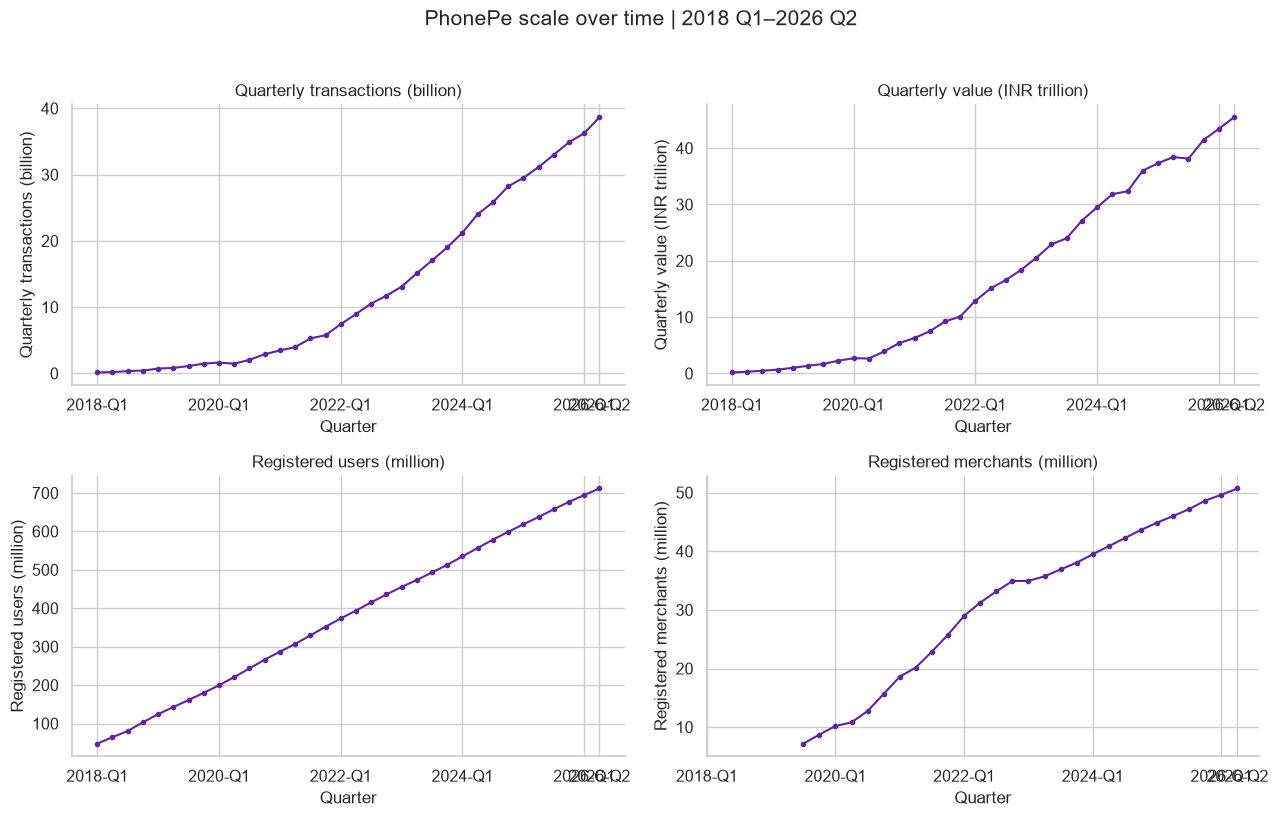

**Insight:** 2026-Q2 has 38.66 billion transactions worth INR 45.50 trillion, 711.65 million users and 50.71 million merchants. The long-run expansion sets a large demand context, but does not establish where a local acceptance gap exists. Registration stocks must not be added across quarters; missing early merchant totals are deliberately shown as gaps rather than an artificial growth baseline.

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
specs = [
    ("transaction_count", 1e9, "Quarterly transactions (billion)"),
    ("transaction_amount", 1e12, "Quarterly value (INR trillion)"),
    ("registered_users", 1e6, "Registered users (million)"),
    ("registered_merchants", 1e6, "Registered merchants (million)"),
]
ticks = sorted(set([0, *range(8, len(national), 8), len(national) - 1]))
for ax, (metric, unit, label) in zip(axes.flat, specs, strict=True):
    ax.plot(national.period_label, national[metric] / unit, color=PURPLE, marker=".")
    ax.set(title=label, xlabel="Quarter", ylabel=label)
    ax.set_xticks(ticks, national.period_label.iloc[ticks])
fig.suptitle("PhonePe scale over time | 2018 Q1–2026 Q2", y=1.02)
save_chart(fig, "02_national_scale")
last = national.iloc[-1]
display(
    Markdown(
        f"**Insight:** {period} has {last.transaction_count / 1e9:.2f} billion transactions worth "
        f"INR {last.transaction_amount / 1e12:.2f} trillion, "
        f"{last.registered_users / 1e6:.2f} million "
        f"users and {last.registered_merchants / 1e6:.2f} million merchants. The "
        f"long-run expansion "
        "sets a large demand context, but does not establish where a local acceptance gap exists. "
        "Registration stocks must not be added across quarters; missing early merchant totals "
        "are deliberately shown as gaps rather than an artificial growth baseline."
    )
)

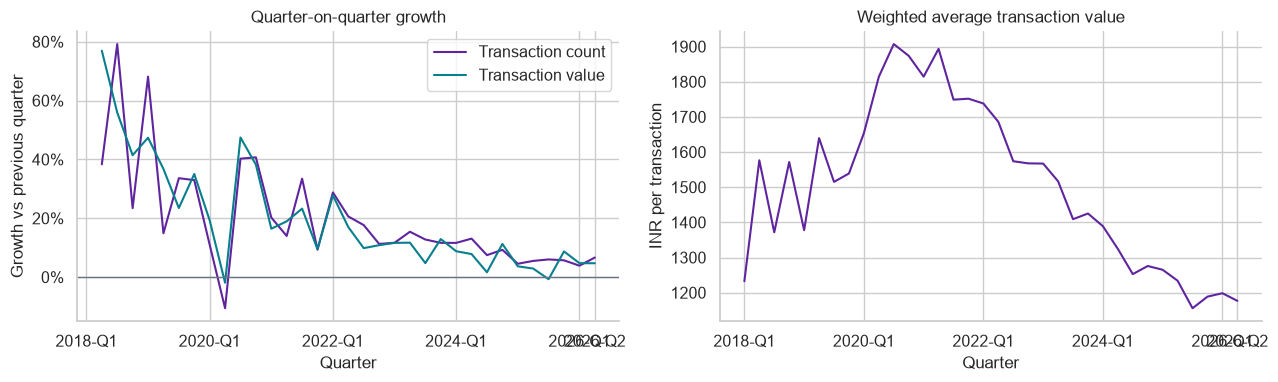

**Insight:** latest transaction growth is 6.66% QoQ; value growth is 4.72%, with a weighted average ticket of INR 1,176.70. Volume and value can grow at different rates because payment mix and ticket size change. Merchant research should distinguish more payment occasions from higher-value payments. Early growth rates have small bases; quarter-of-year patterns below are descriptive, not evidence of a seasonal mechanism.

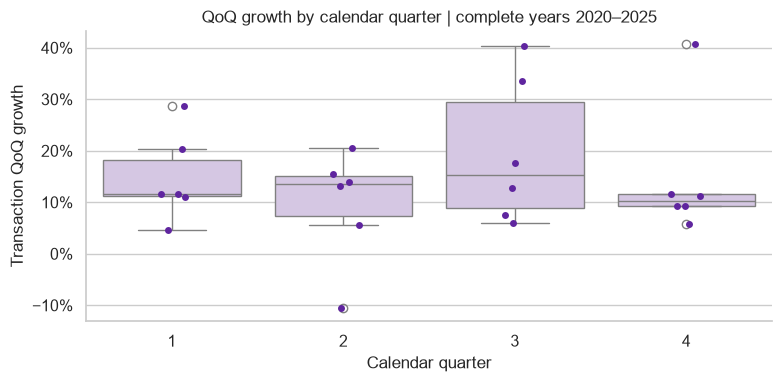

,count,median,min,max
quarter,,,,
1,6,0.117,0.046,0.288
2,6,0.135,-0.106,0.206
3,6,0.152,0.060,0.403
4,6,0.103,0.057,0.407


**Insight:** each quarter has six observations, and within-quarter dispersion shows that calendar position alone does not explain growth. Trend, category mix and changing adoption remain confounded. Use same-quarter YoY alongside QoQ when screening expansion candidates; do not turn this small descriptive sample into a demand forecast.

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for column, label, color in [
    ("transaction_qoq", "Transaction count", PURPLE),
    ("tpv_qoq", "Transaction value", TEAL),
]:
    axes[0].plot(national.period_label, national[column], label=label, color=color)
axes[0].axhline(0, color=GRAY, linewidth=1)
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set(title="Quarter-on-quarter growth", ylabel="Growth vs previous quarter")
axes[0].legend()
axes[1].plot(national.period_label, national.average_transaction_value, color=PURPLE)
axes[1].set(title="Weighted average transaction value", ylabel="INR per transaction")
for ax in axes:
    ax.set_xticks(ticks, national.period_label.iloc[ticks])
    ax.set_xlabel("Quarter")
save_chart(fig, "02_growth_and_ticket_size")
display(
    Markdown(
        f"**Insight:** latest transaction growth is {last.transaction_qoq:.2%} QoQ; "
        f"value growth is "
        f"{last.tpv_qoq:.2%}, with a weighted average ticket of INR "
        f"{last.average_transaction_value:,.2f}. "
        "Volume and value can grow at different rates because payment mix and ticket size change. "
        "Merchant research should distinguish more payment occasions from higher-value payments. "
        "Early growth rates have small bases; quarter-of-year patterns below are descriptive, "
        "not evidence of a seasonal mechanism."
    )
)
season = national.loc[national.year.between(2020, 2025)].copy()
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=season, x="quarter", y="transaction_qoq", color="#D5C2E8", ax=ax)
sns.stripplot(data=season, x="quarter", y="transaction_qoq", color=PURPLE, ax=ax)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set(
    title="QoQ growth by calendar quarter | complete years 2020–2025",
    xlabel="Calendar quarter",
    ylabel="Transaction QoQ growth",
)
save_chart(fig, "02_calendar_quarter_growth")
display(season.groupby("quarter").transaction_qoq.agg(["count", "median", "min", "max"]).round(3))
display(
    Markdown(
        "**Insight:** each quarter has six observations, and within-quarter dispersion "
        "shows that calendar position alone does not explain growth. Trend, category mix "
        "and changing adoption remain confounded. Use same-quarter YoY alongside QoQ "
        "when screening expansion candidates; do not turn this small descriptive sample "
        "into a demand forecast."
    )
)

### Univariate analysis — Size

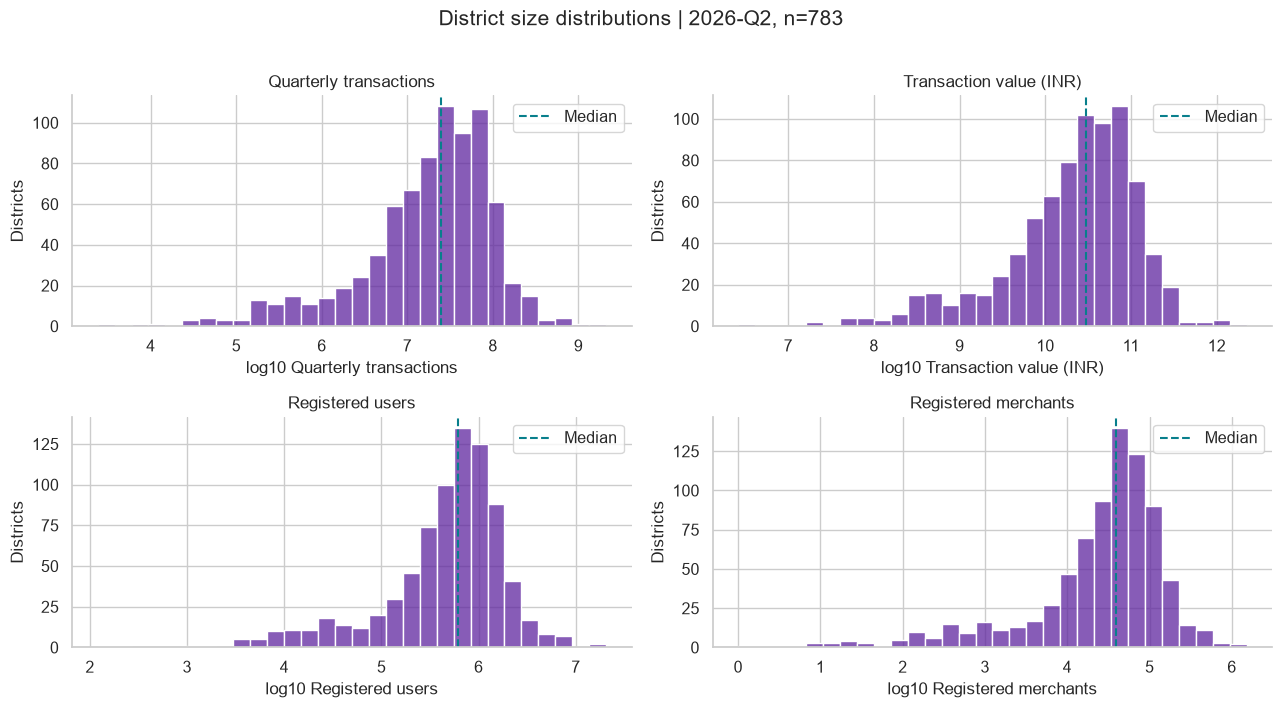

In [5]:
columns = ["transaction_count", "transaction_amount", "registered_users", "registered_merchants"]
fig, axes = plt.subplots(2, 2, figsize=(13, 7.0))
for ax, column in zip(axes.flat, columns, strict=False):
    values = latest[column].dropna()
    use_log = True or column in ["users_per_merchant", "transactions_per_merchant"]
    plotted = np.log10(values.where(values.gt(0)).dropna()) if use_log else values
    sns.histplot(plotted, bins=30, color=PURPLE, ax=ax)
    ax.axvline(plotted.median(), color=TEAL, linestyle="--", label="Median")
    ax.set(
        title=LABELS[column],
        ylabel="Districts",
        xlabel=("log10 " if use_log else "") + LABELS[column],
    )
    if column.endswith(("qoq", "yoy")):
        ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.legend()
for ax in list(axes.flat)[len(columns) :]:
    ax.set_visible(False)
fig.suptitle(f"District size distributions | {period}, n={len(latest)}", y=1.01)
save_chart(fig, "02_distributions_size")

In [6]:
implications = {
    "transaction_count": "Large payment centers dominate absolute demand; smaller "
    "districts still need ratio and growth comparisons before "
    "allocation.",
    "transaction_amount": "Value concentration affects market scale but combines all "
    "categories; it is not merchant revenue.",
    "registered_users": "Registration scale helps size field research, but cannot "
    "substitute for active-user or population penetration.",
    "registered_merchants": "A large registered base can include inactive merchants; "
    "prioritize acceptance verification before assuming dense "
    "coverage.",
}
for column in columns:
    row = stats.loc[column]

    def fmt(value, column=column):
        return f"{value:.2%}" if column.endswith(("qoq", "yoy")) else f"{value:,.2f}"

    display(
        Markdown(
            f"**{LABELS[column]}:** median {fmt(row['50%'])}, mean {fmt(row['mean'])}; "
            f"middle half {fmt(row['25%'])}–{fmt(row['75%'])}; "
            f"{int(row['iqr_outliers'])} observations outside the 1.5×IQR fences, "
            f"{int(row['missing'])} missing. {implications[column]}"
        )
    )

**Quarterly transactions:** median 24,446,442.00, mean 49,379,675.21; middle half 7,906,492.00–57,378,639.50; 49 observations outside the 1.5×IQR fences, 0 missing. Large payment centers dominate absolute demand; smaller districts still need ratio and growth comparisons before allocation.

**Transaction value (INR):** median 29,490,281,720.86, mean 58,105,304,670.34; middle half 9,090,879,407.24–67,391,494,757.20; 51 observations outside the 1.5×IQR fences, 0 missing. Value concentration affects market scale but combines all categories; it is not merchant revenue.

**Registered users:** median 611,315.00, mean 908,880.28; middle half 257,444.00–1,101,086.00; 48 observations outside the 1.5×IQR fences, 0 missing. Registration scale helps size field research, but cannot substitute for active-user or population penetration.

**Registered merchants:** median 38,854.00, mean 64,757.66; middle half 13,414.00–74,654.00; 56 observations outside the 1.5×IQR fences, 0 missing. A large registered base can include inactive merchants; prioritize acceptance verification before assuming dense coverage.

### Univariate analysis — Ratios

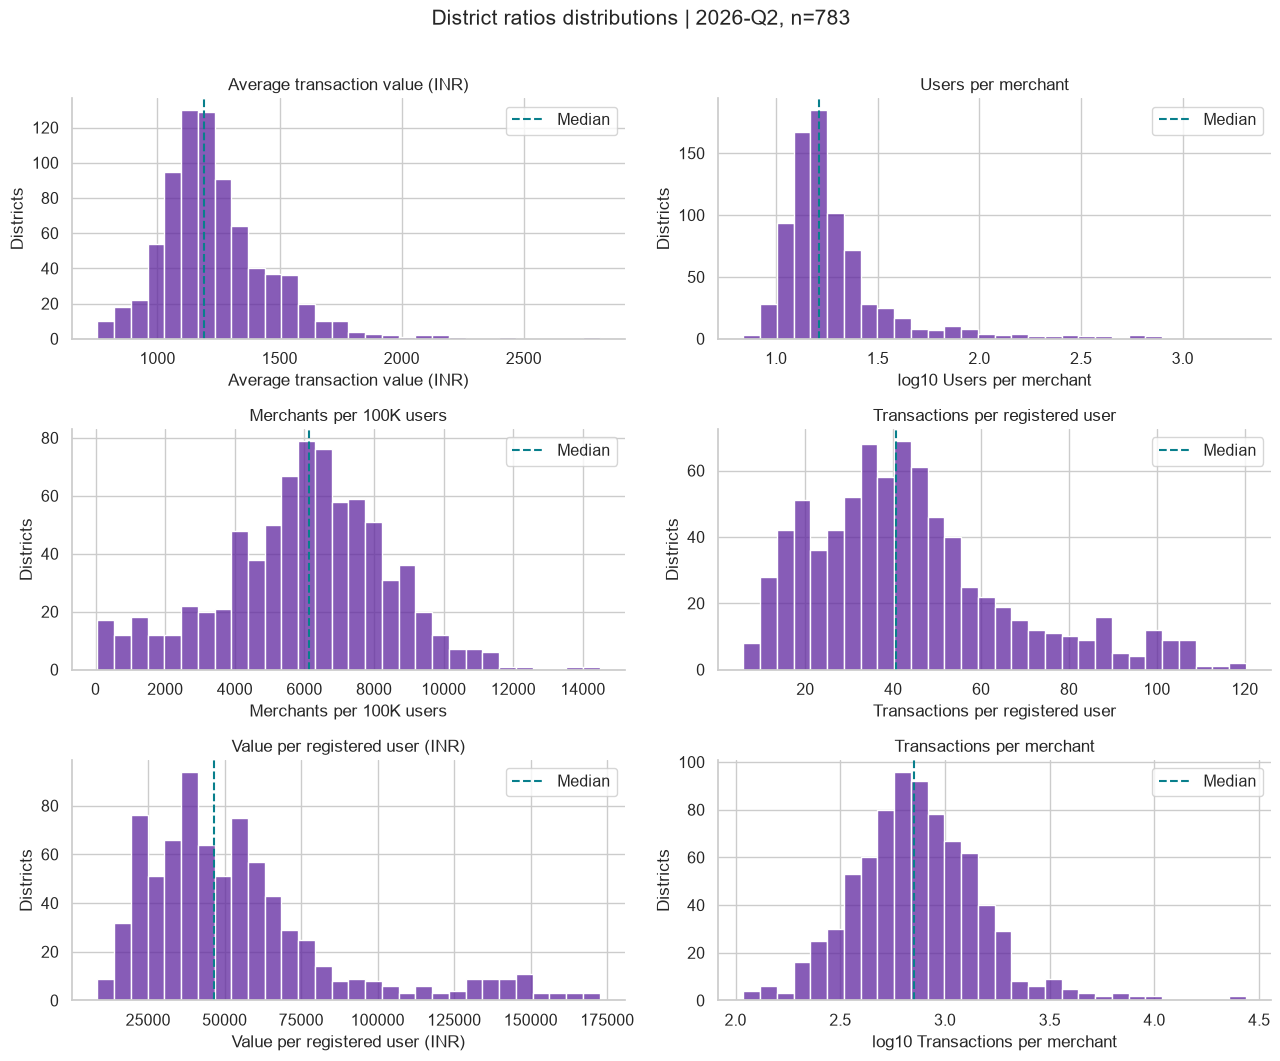

In [7]:
columns = [
    "average_transaction_value",
    "users_per_merchant",
    "merchants_per_100k_users",
    "transactions_per_registered_user",
    "tpv_per_registered_user",
    "transactions_per_merchant",
]
fig, axes = plt.subplots(3, 2, figsize=(13, 10.5))
for ax, column in zip(axes.flat, columns, strict=False):
    values = latest[column].dropna()
    use_log = False or column in ["users_per_merchant", "transactions_per_merchant"]
    plotted = np.log10(values.where(values.gt(0)).dropna()) if use_log else values
    sns.histplot(plotted, bins=30, color=PURPLE, ax=ax)
    ax.axvline(plotted.median(), color=TEAL, linestyle="--", label="Median")
    ax.set(
        title=LABELS[column],
        ylabel="Districts",
        xlabel=("log10 " if use_log else "") + LABELS[column],
    )
    if column.endswith(("qoq", "yoy")):
        ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.legend()
for ax in list(axes.flat)[len(columns) :]:
    ax.set_visible(False)
fig.suptitle(f"District ratios distributions | {period}, n={len(latest)}", y=1.01)
save_chart(fig, "02_distributions_ratios")

In [8]:
implications = {
    "average_transaction_value": "Ticket-size differences may reflect payment mix. "
    "Acquisition offers should be checked against local "
    "merchant categories rather than this aggregate "
    "alone.",
    "users_per_merchant": "Higher values suggest a relative registration gap, not a "
    "proven shortage of shops accepting payments.",
    "merchants_per_100k_users": "This is the inverse registration-density view of "
    "users per merchant. Counting both as score factors "
    "would duplicate the same information.",
    "transactions_per_registered_user": "Activity intensity helps distinguish user "
    "scale from payment frequency, but "
    "registrations are not active users.",
    "tpv_per_registered_user": "Value intensity combines frequency and ticket size; "
    "investigate category mix before inferring higher "
    "commercial value.",
    "transactions_per_merchant": "The tail motivates percentile scoring. P2P "
    "transactions are included, so this is not actual "
    "merchant productivity.",
}
for column in columns:
    row = stats.loc[column]

    def fmt(value, column=column):
        return f"{value:.2%}" if column.endswith(("qoq", "yoy")) else f"{value:,.2f}"

    display(
        Markdown(
            f"**{LABELS[column]}:** median {fmt(row['50%'])}, mean {fmt(row['mean'])}; "
            f"middle half {fmt(row['25%'])}–{fmt(row['75%'])}; "
            f"{int(row['iqr_outliers'])} observations outside the 1.5×IQR fences, "
            f"{int(row['missing'])} missing. {implications[column]}"
        )
    )

**Average transaction value (INR):** median 1,192.24, mean 1,236.84; middle half 1,095.06–1,340.97; 29 observations outside the 1.5×IQR fences, 0 missing. Ticket-size differences may reflect payment mix. Acquisition offers should be checked against local merchant categories rather than this aggregate alone.

**Users per merchant:** median 16.29, mean 32.35; middle half 13.14–22.07; 92 observations outside the 1.5×IQR fences, 0 missing. Higher values suggest a relative registration gap, not a proven shortage of shops accepting payments.

**Merchants per 100K users:** median 6,139.59, mean 5,976.17; middle half 4,530.88–7,609.21; 3 observations outside the 1.5×IQR fences, 0 missing. This is the inverse registration-density view of users per merchant. Counting both as score factors would duplicate the same information.

**Transactions per registered user:** median 40.72, mean 43.93; middle half 27.62–54.06; 38 observations outside the 1.5×IQR fences, 0 missing. Activity intensity helps distinguish user scale from payment frequency, but registrations are not active users.

**Value per registered user (INR):** median 46,491.92, mean 54,191.52; middle half 32,632.15–64,201.29; 64 observations outside the 1.5×IQR fences, 0 missing. Value intensity combines frequency and ticket size; investigate category mix before inferring higher commercial value.

**Transactions per merchant:** median 710.16, mean 1,019.15; middle half 474.76–1,110.09; 42 observations outside the 1.5×IQR fences, 0 missing. The tail motivates percentile scoring. P2P transactions are included, so this is not actual merchant productivity.

### Univariate analysis — Growth

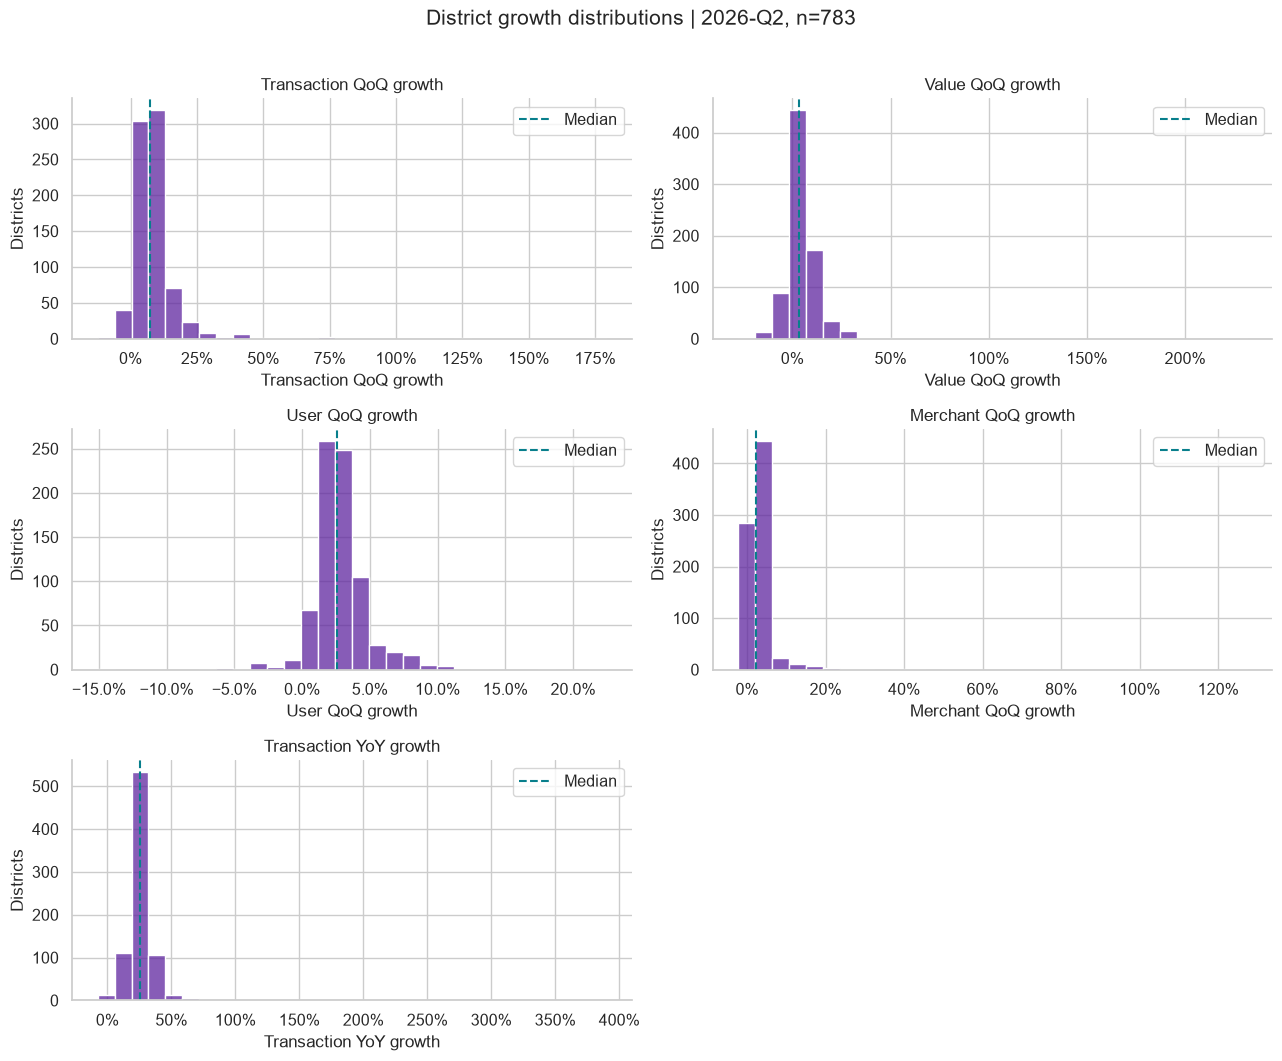

In [9]:
columns = ["transaction_qoq", "tpv_qoq", "user_qoq", "merchant_qoq", "transaction_yoy"]
fig, axes = plt.subplots(3, 2, figsize=(13, 10.5))
for ax, column in zip(axes.flat, columns, strict=False):
    values = latest[column].dropna()
    use_log = False or column in ["users_per_merchant", "transactions_per_merchant"]
    plotted = np.log10(values.where(values.gt(0)).dropna()) if use_log else values
    sns.histplot(plotted, bins=30, color=PURPLE, ax=ax)
    ax.axvline(plotted.median(), color=TEAL, linestyle="--", label="Median")
    ax.set(
        title=LABELS[column],
        ylabel="Districts",
        xlabel=("log10 " if use_log else "") + LABELS[column],
    )
    if column.endswith(("qoq", "yoy")):
        ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.legend()
for ax in list(axes.flat)[len(columns) :]:
    ax.set_visible(False)
fig.suptitle(f"District growth distributions | {period}, n={len(latest)}", y=1.01)
save_chart(fig, "02_distributions_growth")

In [10]:
implications = {
    "transaction_qoq": "Short-term momentum must be read with its base size and YoY "
    "growth; a single quarter can be noisy.",
    "tpv_qoq": "Compare value growth with count growth to identify a changing ticket "
    "mix rather than assuming more payment occasions.",
    "user_qoq": "Registration growth is an adoption proxy; it does not demonstrate "
    "activation or retention.",
    "merchant_qoq": "Registration additions are supply-side context. New "
    "registrations without activity would need an activation response.",
    "transaction_yoy": "Year-over-year comparisons align calendar quarters but still "
    "depend on stable geography and comparable reporting.",
}
for column in columns:
    row = stats.loc[column]

    def fmt(value, column=column):
        return f"{value:.2%}" if column.endswith(("qoq", "yoy")) else f"{value:,.2f}"

    display(
        Markdown(
            f"**{LABELS[column]}:** median {fmt(row['50%'])}, mean {fmt(row['mean'])}; "
            f"middle half {fmt(row['25%'])}–{fmt(row['75%'])}; "
            f"{int(row['iqr_outliers'])} observations outside the 1.5×IQR fences, "
            f"{int(row['missing'])} missing. {implications[column]}"
        )
    )

**Transaction QoQ growth:** median 7.28%, mean 8.89%; middle half 4.44%–10.70%; 49 observations outside the 1.5×IQR fences, 0 missing. Short-term momentum must be read with its base size and YoY growth; a single quarter can be noisy.

**Value QoQ growth:** median 3.57%, mean 5.52%; middle half 0.71%–7.85%; 60 observations outside the 1.5×IQR fences, 0 missing. Compare value growth with count growth to identify a changing ticket mix rather than assuming more payment occasions.

**User QoQ growth:** median 2.58%, mean 2.83%; middle half 1.78%–3.56%; 67 observations outside the 1.5×IQR fences, 0 missing. Registration growth is an adoption proxy; it does not demonstrate activation or retention.

**Merchant QoQ growth:** median 2.38%, mean 3.67%; middle half 1.72%–3.26%; 70 observations outside the 1.5×IQR fences, 0 missing. Registration additions are supply-side context. New registrations without activity would need an activation response.

**Transaction YoY growth:** median 25.33%, mean 26.13%; middle half 20.75%–29.81%; 37 observations outside the 1.5×IQR fences, 0 missing. Year-over-year comparisons align calendar quarters but still depend on stable geography and comparable reporting.

### Geographic concentration — activity share versus district count

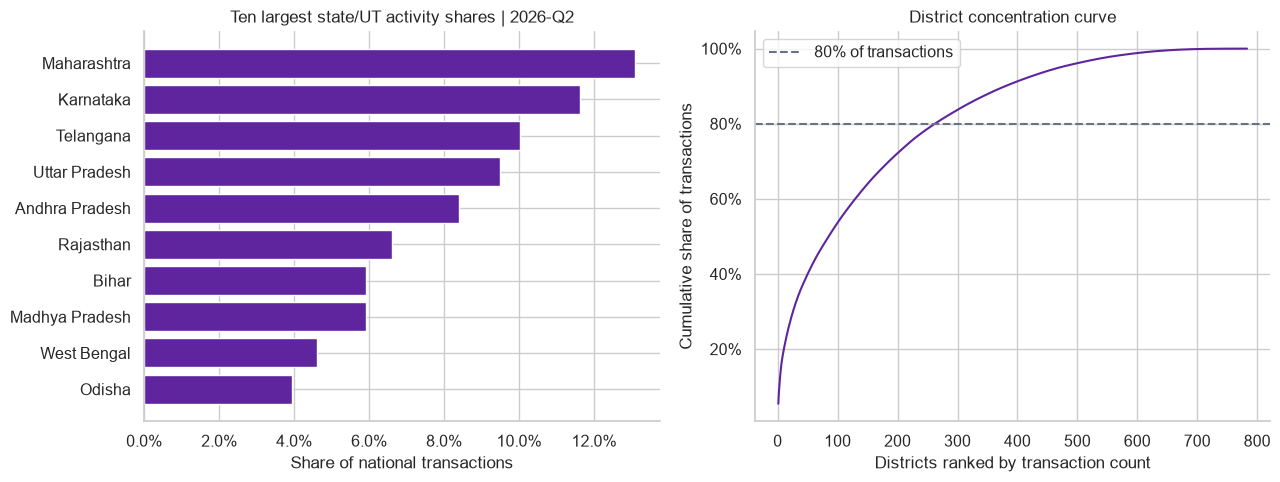

,districts,median_users_per_merchant
state,,
uttar pradesh,75,11.75
madhya pradesh,55,14.55
rajasthan,41,15.01
bihar,38,14.63
tamil nadu,38,16.84
maharashtra,36,16.57
assam,35,14.93
gujarat,34,20.00
telangana,33,15.24


**Insight:** the top five states contribute 52.6% of transactions. The largest 263 of 783 districts reach 80% of volume. Concentration makes large markets operationally relevant, but the number of districts in a state also reflects administrative geography. Rank activity and local opportunity separately; do not treat a state with more districts as inherently more attractive.

In [11]:
leaders = state_latest.sort_values("transaction_count", ascending=False).copy()
leaders["share"] = leaders.transaction_count / leaders.transaction_count.sum()
leaders["cumulative_share"] = leaders.share.cumsum()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
shown = leaders.head(10).sort_values("share")
axes[0].barh(shown.state.str.title(), shown.share, color=PURPLE)
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[0].set(
    title=f"Ten largest state/UT activity shares | {period}",
    xlabel="Share of national transactions",
)
ranked_districts = latest.transaction_count.sort_values(ascending=False)
cumulative = ranked_districts.cumsum() / ranked_districts.sum()
axes[1].plot(np.arange(1, len(cumulative) + 1), cumulative, color=PURPLE)
axes[1].axhline(0.8, color=GRAY, linestyle="--", label="80% of transactions")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set(
    title="District concentration curve",
    xlabel="Districts ranked by transaction count",
    ylabel="Cumulative share of transactions",
)
axes[1].legend()
save_chart(fig, "02_geographic_concentration")
display(
    latest.groupby("state")
    .agg(districts=("district", "size"), median_users_per_merchant=("users_per_merchant", "median"))
    .sort_values("districts", ascending=False)
    .head(10)
    .round(2)
)
display(
    Markdown(
        f"**Insight:** the top five states contribute "
        f"{leaders.head(5).share.sum():.1%} of transactions. "
        f"The largest {int((cumulative < 0.8).sum() + 1)} of {len(latest)} districts "
        f"reach 80% of volume. "
        "Concentration makes large markets operationally relevant, but the number of districts in "
        "a state also reflects administrative geography. Rank activity and local "
        "opportunity separately; "
        "do not treat a state with more districts as inherently more attractive."
    )
)

### Category mix — national evolution and state differences

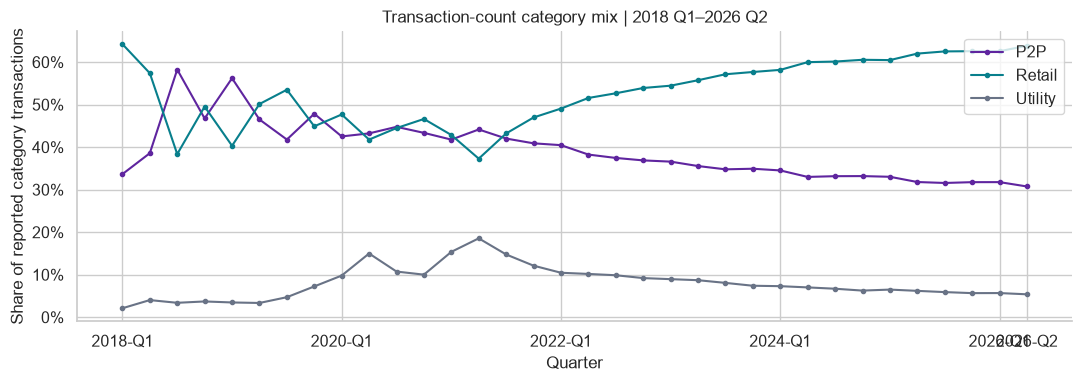

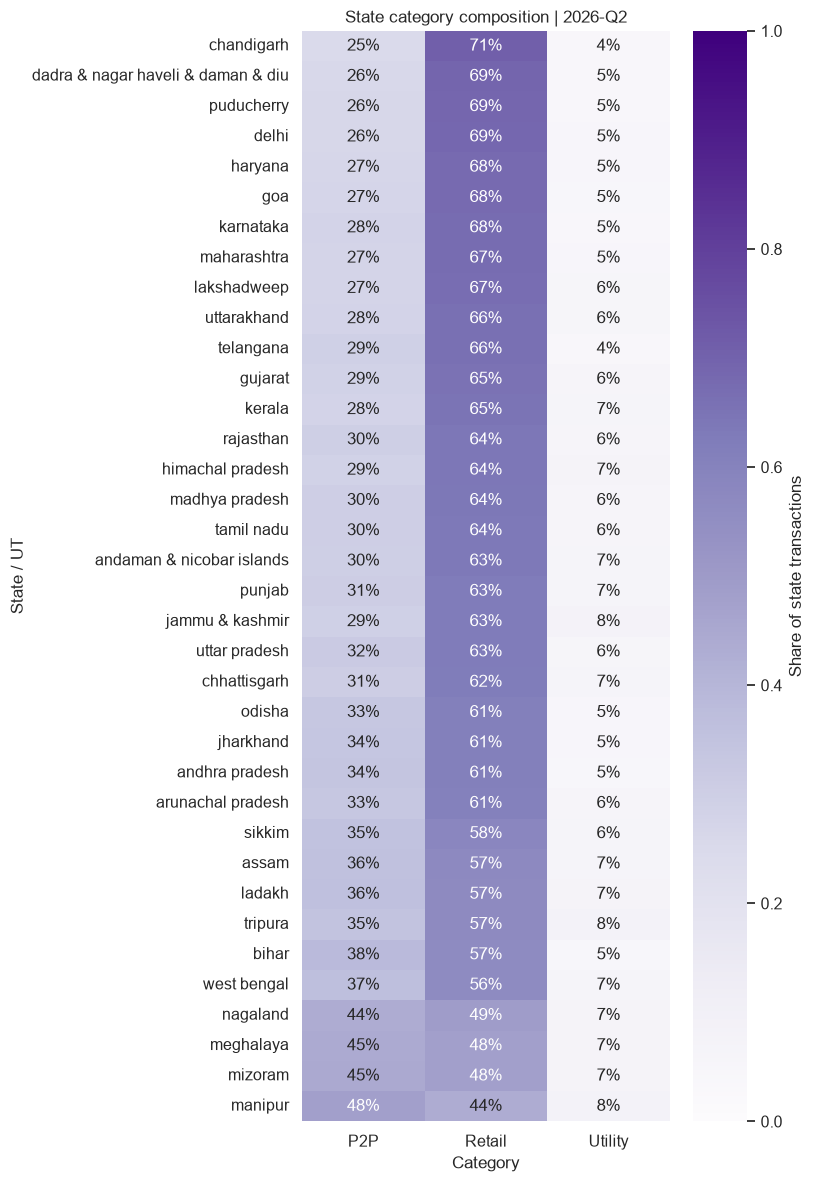

,count,sum,median,min,max
category,,,,,
P2P,36,11889781621,84381384.0,101796,1389123843
Retail,36,24691181013,184457583.5,248709,3413003601
Utility,36,2083323057,19667977.0,20691,262324547


**Insight:** Retail accounts for 63.9% of latest national transactions, versus 64.2% initially. Latest state Retail shares range from 43.5% to 71.0%. Payment-purpose mix therefore changes the commercial meaning of identical district transaction totals. Use state Retail share as context for field research, not as an estimated Retail share for every district. Source categories contain counts only, so category ticket sizes and revenues cannot be inferred.

In [12]:
categories = pd.read_parquet(PROCESSED_DIR / "state_transaction_categories.parquet")
category_totals = categories.groupby(["period_id", "category"]).transaction_count.sum().unstack()
category_shares = category_totals.div(category_totals.sum(axis=1), axis=0)
palette = {"P2P": PURPLE, "Retail": TEAL, "Utility": GRAY}
fig, ax = plt.subplots(figsize=(11, 4))
for category in category_shares:
    ax.plot(
        national.period_label,
        category_shares[category],
        label=category,
        color=palette[category],
        marker=".",
    )
ax.set_xticks(ticks, national.period_label.iloc[ticks])
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set(
    title="Transaction-count category mix | 2018 Q1–2026 Q2",
    xlabel="Quarter",
    ylabel="Share of reported category transactions",
)
ax.legend()
save_chart(fig, "02_category_mix_over_time")
category_latest = categories.loc[categories.period_id.eq(latest_period)]
mix = category_latest.pivot(index="state", columns="category", values="transaction_count")
mix = mix.div(mix.sum(axis=1), axis=0).sort_values("Retail", ascending=False)
fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(
    mix.astype(float),
    cmap="Purples",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".0%",
    cbar_kws={"label": "Share of state transactions"},
    ax=ax,
)
ax.set(title=f"State category composition | {period}", ylabel="State / UT", xlabel="Category")
save_chart(fig, "02_state_category_mix")
display(
    category_latest.groupby("category").transaction_count.agg(
        ["count", "sum", "median", "min", "max"]
    )
)
display(
    Markdown(
        f"**Insight:** Retail accounts for {category_shares.iloc[-1]['Retail']:.1%} of "
        f"latest national "
        f"transactions, versus {category_shares.iloc[0]['Retail']:.1%} initially. "
        f"Latest state Retail "
        f"shares range from {mix.Retail.min():.1%} to {mix.Retail.max():.1%}. Payment-purpose mix "
        "therefore changes the commercial meaning of identical district transaction totals. "
        "Use state Retail share as context for field research, not as an estimated Retail share "
        "for every district. Source categories contain counts only, so category ticket sizes "
        "and revenues cannot be inferred."
    )
)

### Bivariate analysis — user scale, merchants and payment activity

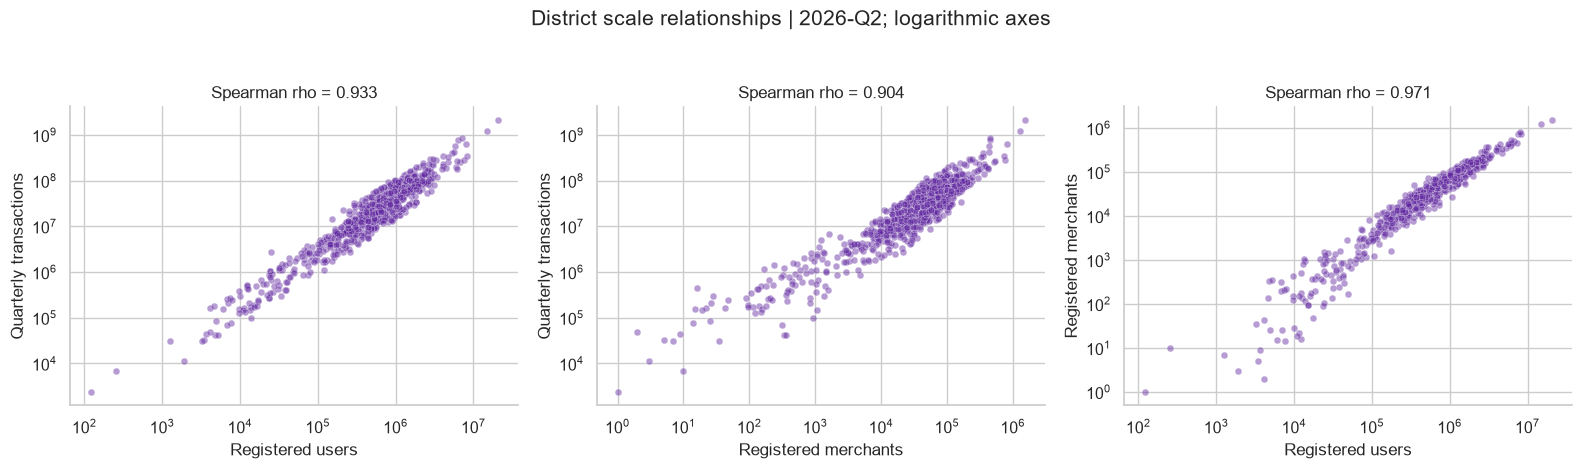

**Insight:** the displayed positive scale associations show why raw transaction leaders also tend to have large user/merchant bases. This does not identify the effect of adding merchants. Compare per-user demand and relative merchant density alongside size; logarithmic axes reveal the smaller districts without discarding large markets.

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
pairs = [
    ("registered_users", "transaction_count"),
    ("registered_merchants", "transaction_count"),
    ("registered_users", "registered_merchants"),
]
for ax, (x, y) in zip(axes, pairs, strict=True):
    sns.scatterplot(data=latest, x=x, y=y, color=PURPLE, alpha=0.45, s=24, ax=ax)
    ax.set(xscale="log", yscale="log", xlabel=LABELS[x], ylabel=LABELS[y])
    rho = latest[[x, y]].corr(method="spearman").iloc[0, 1]
    ax.set_title(f"Spearman rho = {rho:.3f}")
fig.suptitle(f"District scale relationships | {period}; logarithmic axes", y=1.04)
save_chart(fig, "02_scale_relationships")
display(
    Markdown(
        "**Insight:** the displayed positive scale associations show why raw transaction "
        "leaders also tend to have large user/merchant bases. This does not identify the "
        "effect of adding merchants. Compare per-user demand and relative merchant "
        "density alongside size; logarithmic axes reveal the smaller districts without "
        "discarding large markets."
    )
)

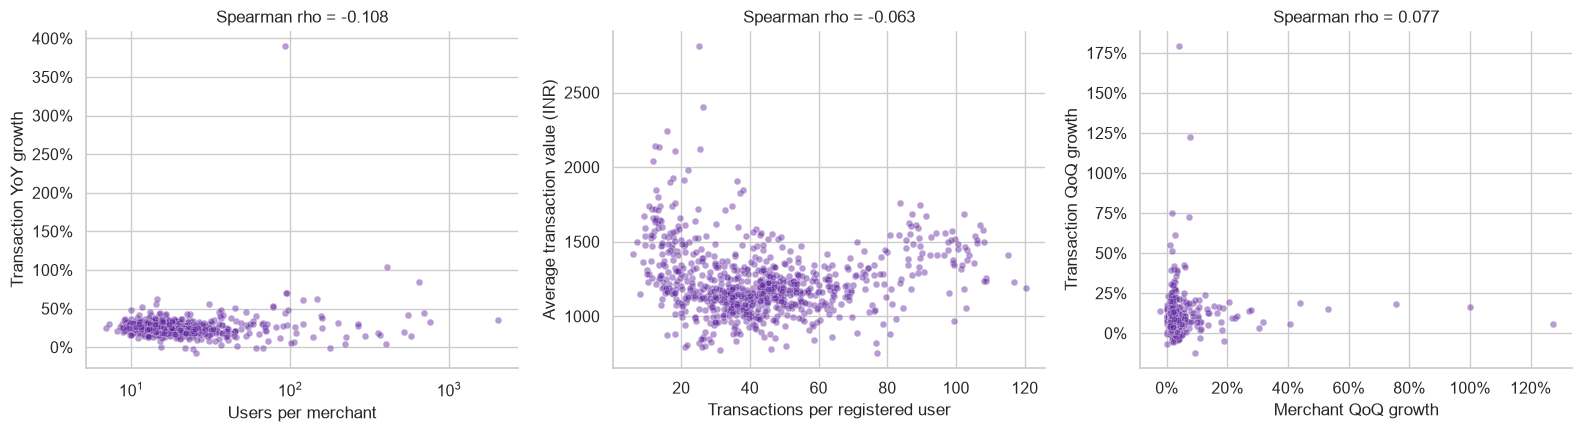

**Insight:** density versus growth is a screening relationship, not a target merchant ratio. Frequency versus ticket size distinguishes types of payment activity, while merchant versus transaction growth highlights places where registrations and usage move differently. None supplies causal evidence; the ratios can share denominators, and a common local adoption trend can move both series. Validate active acceptance and payment category on the ground.

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
pairs = [
    ("users_per_merchant", "transaction_yoy"),
    ("transactions_per_registered_user", "average_transaction_value"),
    ("merchant_qoq", "transaction_qoq"),
]
for ax, (x, y) in zip(axes, pairs, strict=True):
    sns.scatterplot(data=latest, x=x, y=y, color=PURPLE, alpha=0.45, s=24, ax=ax)
    rho = latest[[x, y]].corr(method="spearman").iloc[0, 1]
    ax.set(title=f"Spearman rho = {rho:.3f}", xlabel=LABELS[x], ylabel=LABELS[y])
    if x.endswith("qoq"):
        ax.xaxis.set_major_formatter(PercentFormatter(1))
    if x == "users_per_merchant":
        ax.set_xscale("log")
    if y.endswith(("qoq", "yoy")):
        ax.yaxis.set_major_formatter(PercentFormatter(1))
save_chart(fig, "02_demand_density_and_momentum")
display(
    Markdown(
        "**Insight:** density versus growth is a screening relationship, not a target "
        "merchant ratio. Frequency versus ticket size distinguishes types of payment "
        "activity, while merchant versus transaction growth highlights places where "
        "registrations and usage move differently. None supplies causal evidence; "
        "the ratios can share denominators, and a common local adoption trend can "
        "move both series. Validate active acceptance and payment category on the ground."
    )
)

### Multivariate analysis — does the density/growth relationship survive user-scale groups?

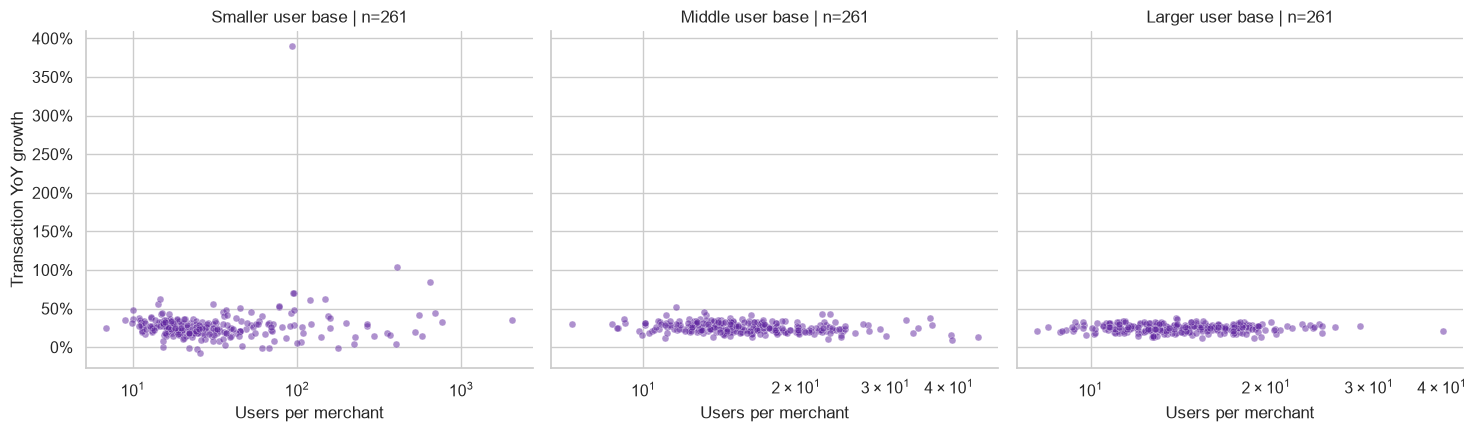

,User scale,Districts,Spearman rho,Median users
0,Smaller,261,-0.095,150289.0
1,Middle,261,-0.238,611315.0
2,Larger,261,0.023,1416945.0


**Insight:** stratifying by the registered-user base reveals whether the pooled density/growth pattern also appears among districts of similar scale. The displayed group correlations describe heterogeneous associations, not a causal adjustment. Prefer candidates with adequate scale and sustained growth over a universal penetration cutoff; state composition and local categories still differ within each group.

In [15]:
latest["user_scale"] = pd.qcut(latest.registered_users, 3, labels=["Smaller", "Middle", "Larger"])
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=False, sharey=True)
scale_results = []
for ax, (group, rows) in zip(axes, latest.groupby("user_scale", observed=True), strict=True):
    sns.scatterplot(
        data=rows, x="users_per_merchant", y="transaction_yoy", color=PURPLE, alpha=0.5, s=25, ax=ax
    )
    rho = rows[["users_per_merchant", "transaction_yoy"]].corr(method="spearman").iloc[0, 1]
    scale_results.append(
        {
            "User scale": group,
            "Districts": len(rows),
            "Spearman rho": rho,
            "Median users": rows.registered_users.median(),
        }
    )
    ax.set(
        title=f"{group} user base | n={len(rows)}",
        xlabel="Users per merchant",
        ylabel="Transaction YoY growth",
    )
    ax.set_xscale("log")
    ax.yaxis.set_major_formatter(PercentFormatter(1))
save_chart(fig, "02_growth_density_by_user_scale")
display(pd.DataFrame(scale_results).round(3))
display(
    Markdown(
        "**Insight:** stratifying by the registered-user base reveals whether the pooled "
        "density/growth pattern also appears among districts of similar scale. "
        "The displayed group correlations describe heterogeneous associations, not "
        "a causal adjustment. Prefer candidates with adequate scale and sustained growth "
        "over a universal penetration cutoff; state composition and local categories "
        "still differ within each group."
    )
)

## Takeaways
Absolute activity is concentrated, so robust distribution summaries and relative metrics add information beyond a top-volume list. State category mix changes how district demand should be interpreted. Ratios and growth give complementary signals, but overlapping denominators and reporting geography limit causal conclusions. The next notebook quantifies outlier influence and within-state associations; the final notebook tests how those choices change the investigation queue.